In [1]:
import pandas as pd
import hvplot.pandas
import panel as pn
import hvplot
import plotly.express as px
pn.extension()
import plotly.graph_objects as go

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
df

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source,Weapon_Group,Relationship_Group,Perpetrator_Age_Available
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1.0,Murder or Manslaughter,...,Native American/Alaska Native,NaN,Acquaintance,Blunt Object,0.0,0.0,FBI,Blunt Object,Known,True
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Strangulation,0.0,0.0,FBI,Other,Known,True
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2.0,Murder or Manslaughter,...,NaN,NaN,NaN,NaN,0.0,0.0,FBI,Unknown,Unknown,False
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Strangulation,0.0,0.0,FBI,Other,Known,True
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2.0,Murder or Manslaughter,...,NaN,NaN,NaN,NaN,0.0,1.0,FBI,Unknown,Unknown,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465681,465682,WY01301,Casper,Municipal Police,Natrona,Wyoming,2003,August,1.0,Murder or Manslaughter,...,White,NaN,Son,Blunt Object,0.0,0.0,FBI,Blunt Object,Family,True
465682,465683,WY01301,Casper,Municipal Police,Natrona,Wyoming,2003,September,1.0,Murder or Manslaughter,...,White,NaN,Wife,Blunt Object,0.0,0.0,FBI,Blunt Object,Partner,True
465683,465684,WY01304,Evansville,Municipal Police,Natrona,Wyoming,2003,July,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Blunt Object,0.0,0.0,FBI,Blunt Object,Known,True
465684,465685,WY01900,Sweetwater,Sheriff,Sweetwater,Wyoming,2003,January,1.0,Murder or Manslaughter,...,White,NaN,In-Law,Rifle,0.0,0.0,FBI,Firearm,Other,True


In [4]:
df_trend = df[df['Year'] < 2004]

df_trend

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source,Weapon_Group,Relationship_Group,Perpetrator_Age_Available
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1.0,Murder or Manslaughter,...,Native American/Alaska Native,NaN,Acquaintance,Blunt Object,0.0,0.0,FBI,Blunt Object,Known,True
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Strangulation,0.0,0.0,FBI,Other,Known,True
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2.0,Murder or Manslaughter,...,NaN,NaN,NaN,NaN,0.0,0.0,FBI,Unknown,Unknown,False
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Strangulation,0.0,0.0,FBI,Other,Known,True
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2.0,Murder or Manslaughter,...,NaN,NaN,NaN,NaN,0.0,1.0,FBI,Unknown,Unknown,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465681,465682,WY01301,Casper,Municipal Police,Natrona,Wyoming,2003,August,1.0,Murder or Manslaughter,...,White,NaN,Son,Blunt Object,0.0,0.0,FBI,Blunt Object,Family,True
465682,465683,WY01301,Casper,Municipal Police,Natrona,Wyoming,2003,September,1.0,Murder or Manslaughter,...,White,NaN,Wife,Blunt Object,0.0,0.0,FBI,Blunt Object,Partner,True
465683,465684,WY01304,Evansville,Municipal Police,Natrona,Wyoming,2003,July,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Blunt Object,0.0,0.0,FBI,Blunt Object,Known,True
465684,465685,WY01900,Sweetwater,Sheriff,Sweetwater,Wyoming,2003,January,1.0,Murder or Manslaughter,...,White,NaN,In-Law,Rifle,0.0,0.0,FBI,Firearm,Other,True


In [5]:
yearly_incidents = (
    df_trend[['Year', 'Month', 'City', 'Incident']]
    .drop_duplicates()
    .groupby('Year')
    .size()
    .reset_index(name='Total_Incidents')
)

yearly_incidents

,Year,Total_Incidents
0,1980,17056
1,1981,15963
2,1982,15157
3,1983,14868
4,1984,13429
5,1985,13490
6,1986,14887
7,1987,13897
8,1988,14494
9,1989,15271


In [6]:
year_slider = pn.widgets.IntRangeSlider(
    name='Select Year Range',
    start=yearly_incidents['Year'].min(),
    end=yearly_incidents['Year'].max(),
    value=(yearly_incidents['Year'].min(), yearly_incidents['Year'].max())
)

In [7]:
@pn.depends(year_slider)
def trend_plot(year_range):
    filtered = yearly_incidents[
        (yearly_incidents['Year'] >= year_range[0]) &
        (yearly_incidents['Year'] <= year_range[1])
    ]

    return filtered.hvplot.line(
        x='Year',
        y='Total_Incidents',
        line_width=3,
        color='#00D4FF',
        title="Incident Trend Over Time",
        height=400,
        width=800
    ).opts(
        bgcolor='#0A0F1C',
        show_grid=False
    )

In [8]:
pn.Column(year_slider, trend_plot)

Column
    [0] IntRangeSlider(end=np.int64(2003), name='Select Year Range', start=np.int64(1980), value=(np.int64(1980), ..., value_end=np.int64(2003), value_start=np.int64(1980))
    [1] ParamFunction(function, _pane=HoloViews, defer_load=False)

### Incidents follow a phased pattern, peaking sharply around 1992–93 before a sustained decline through the late 1990s. The drop is steep and consistent, indicating a structural shift rather than random fluctuation, with partial stabilization observed after 2000.

#### The pattern suggests that the variation is not random noise but occurs in distinct phases, indicating underlying systemic factors influencing crime rates rather than isolated yearly changes.

In [9]:
state_data = (
    df_trend[['State', 'Year', 'Month', 'City', 'Incident']]
    .drop_duplicates()
    .groupby('State')
    .size()
    .reset_index(name='Total_Incidents')
    .sort_values(by='Total_Incidents', ascending=False)
)

top_states = state_data.head(10)
top_states

,State,Total_Incidents
4,California,42583
43,Texas,38351
32,New York,37906
13,Illinois,18375
22,Michigan,17827
9,Florida,15077
38,Pennsylvania,14154
10,Georgia,12957
18,Louisiana,12701
33,North Carolina,12341


In [10]:
top_states.hvplot.barh(
    x='State',
    y='Total_Incidents',
    color='#7B61FF',
    title="Top 10 States by Incidents",
    height=400,
    width=800
).opts(
    bgcolor='#0A0F1C',
    show_grid=False,
    tools=['hover'],
    toolbar='right'
)

:Bars   [State]   (Total_Incidents)

### Crime incidents are highly concentrated, with California clearly dominating, followed by Texas and New York. A sharp drop after the top three indicates that a small number of states account for a disproportionately large share of total incidents.

#### This distribution suggests that crime is not evenly spread geographically, but clustered in high-population or high-density states.

In [11]:
weapon_data = (
    df_trend[['Weapon_Group', 'Year', 'Month', 'City', 'Incident']]
    .drop_duplicates()
    .groupby('Weapon_Group')
    .size()
    .reset_index(name='Total_Incidents')
    .sort_values(by='Total_Incidents', ascending=False)
)

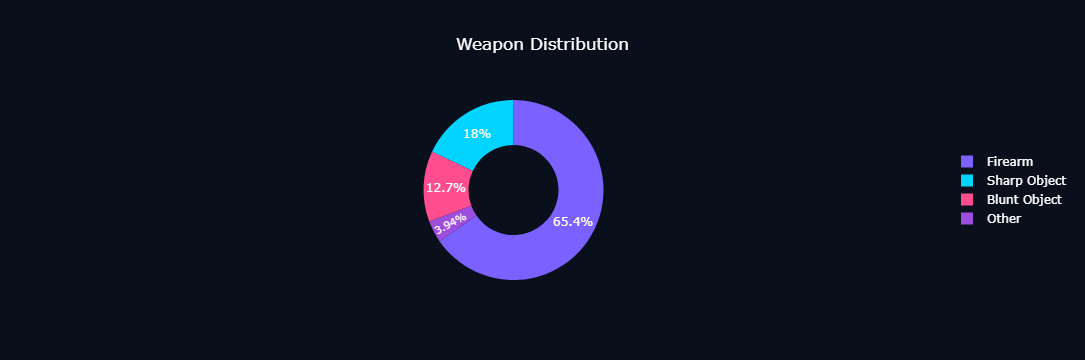

In [12]:
top_weapons = (
    weapon_data[weapon_data['Weapon_Group'] != 'Unknown']
    .head(6)
)

fig = px.pie(
    top_weapons,
    names='Weapon_Group',
    values='Total_Incidents',
    hole=0.5,
    color_discrete_sequence=[
        '#7B61FF', '#00D4FF', '#FF4D8D',
        '#9D4EDD', '#4CC9F0', '#F72585'
    ],
    title="Weapon Distribution"
)
fig.update_layout(
    paper_bgcolor='#0A0F1C',
    plot_bgcolor='#0A0F1C',
    font_color='white',
    title_x=0.5   # center title
)

fig.update_traces(
    textinfo='percent',
    textposition='inside',
    textfont=dict(color='white')
)
fig.update_layout(
    legend=dict(
        orientation="v",
        x=1,
        y=0.5
    )
)
fig.show()

#### The distribution clearly shows a strong concentration in firearm usage, which suggests that incident methods are not diverse but heavily reliant on a single dominant category. This could indicate factors such as accessibility, effectiveness, or reporting bias influencing weapon choice.

In [13]:
relationship_data = (
    df_trend[['Relationship_Group', 'Year', 'Month', 'City', 'Incident']]
    .drop_duplicates()
    .groupby('Relationship_Group')
    .size()
    .reset_index(name='Total_Incidents')
    .sort_values(by='Total_Incidents', ascending=False)
)

relationship_data

,Relationship_Group,Total_Incidents
6,Unknown,155008
1,Known,107106
5,Stranger,63947
3,Partner,43854
0,Family,17973
2,Other,9441
4,Sibling,4971


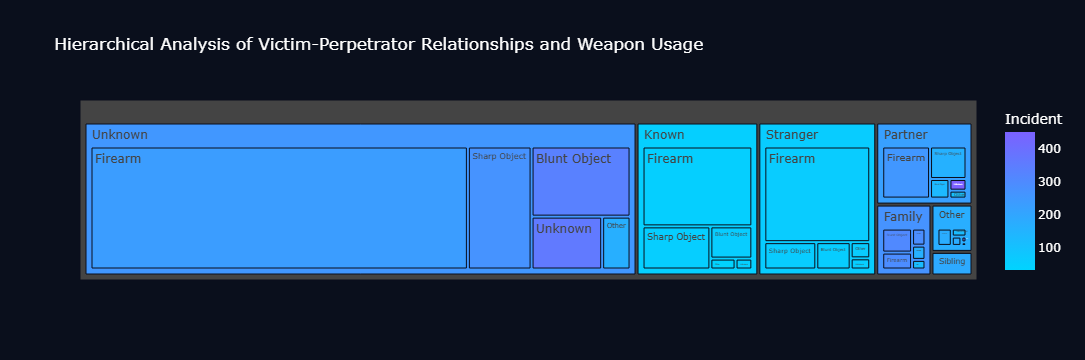

In [14]:
top_rel = relationship_data.head(6)

fig = px.treemap(
    df_trend,
    path=['Relationship_Group', 'Weapon_Group'],
    values='Incident',
    color='Incident',
    color_continuous_scale=['#00D4FF', '#7B61FF'],
    title="Hierarchical Analysis of Victim-Perpetrator Relationships and Weapon Usage"
)

fig.update_layout(
    paper_bgcolor='#0A0F1C',
    font_color='white'
)

fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Incidents: %{value}<extra></extra>"
)

fig.show()

### A large proportion of incidents fall under unknown relationships, with firearms dominating across most categories, indicating both data limitations and strong weapon concentration patterns.

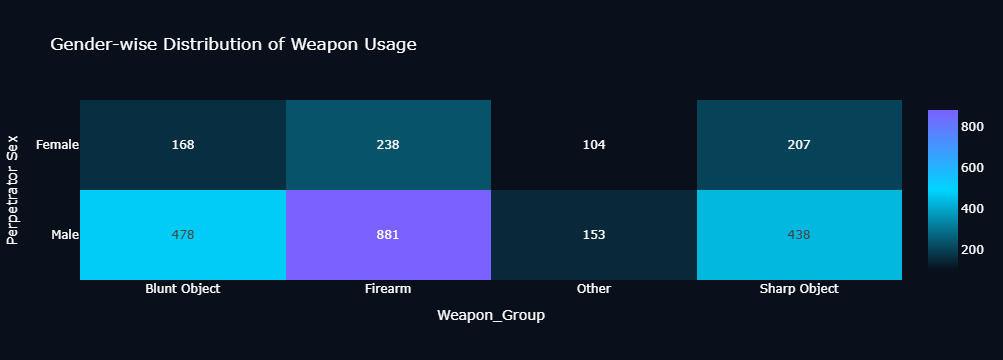

In [18]:
heatmap_data = ( 
    df_trend[['Perpetrator Sex', 'Weapon_Group', 'Incident']] 
        .drop_duplicates() 
        .groupby(['Perpetrator Sex', 'Weapon_Group']) 
        .size() .reset_index(name='Total_Incidents') 
)
heatmap_pivot = heatmap_data.pivot( 
    index='Perpetrator Sex', 
    columns='Weapon_Group', 
    values='Total_Incidents' 
).fillna(0) 
heatmap_pivot = heatmap_pivot.drop(columns=['Unknown'], errors='ignore') 
fig = px.imshow( 
    heatmap_pivot, 
    text_auto=True,
    color_continuous_scale=['#0A0F1C', '#00D4FF', '#7B61FF'], 
    aspect='auto', title="Gender-wise Distribution of Weapon Usage" 
)
fig.update_traces( hovertemplate="<b>Gender:</b> %{y}<br><b>Weapon:</b> %{x}<br><b>Incidents:</b> %{z}<extra></extra>" ) 
fig.update_layout(
    paper_bgcolor='#0A0F1C', 
    font_color='white', 
    hovermode='closest' 
)

fig.show()

### Weapon usage is heavily skewed toward male perpetrators, with firearms showing the strongest dominance across genders.
#### The same pattern across weapon types shows the difference is consistent, not limited to one category.

In [19]:
bubble_data = (
    df_trend[['Year', 'Relationship_Group', 'Weapon_Group', 'Perpetrator Sex', 'Incident']]
    .drop_duplicates()
    .groupby(['Year', 'Relationship_Group', 'Weapon_Group', 'Perpetrator Sex'])
    .size()
    .reset_index(name='Total_Incidents')
)

bubble_data = bubble_data[bubble_data['Relationship_Group'] != 'Unknown']
bubble_data = bubble_data[bubble_data['Weapon_Group'] != 'Unknown']
category_orders = {
    "Weapon_Group": ['Blunt Object', 'Firearm', 'Sharp Object', 'Other', 'Unknown'],
    "Relationship_Group": ['Family', 'Known', 'Partner', 'Sibling', 'Stranger', 'Unknown']
}
years = sorted(bubble_data['Year'].unique())

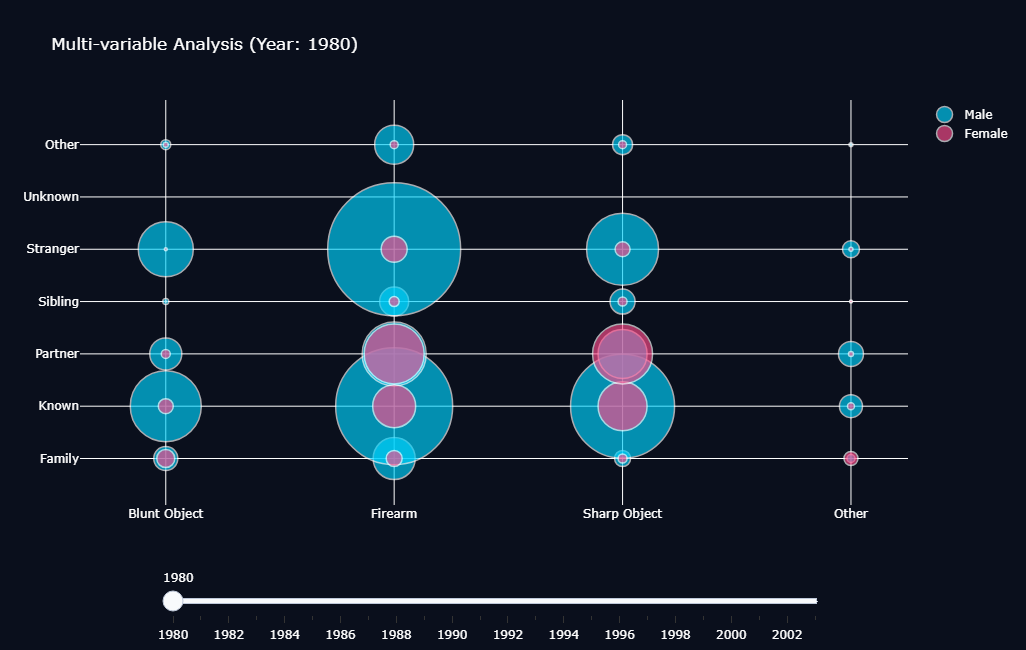

In [20]:
initial_year = years[0]

df_init = bubble_data[bubble_data['Year'] == initial_year]

male_init = df_init[df_init['Perpetrator Sex'] == 'Male']
female_init = df_init[df_init['Perpetrator Sex'] == 'Female']

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=male_init['Weapon_Group'],
    y=male_init['Relationship_Group'],
    mode='markers',
    marker=dict(size=male_init['Total_Incidents'], color='#00D4FF'),
    name='Male'
))

fig.add_trace(go.Scatter(
    x=female_init['Weapon_Group'],
    y=female_init['Relationship_Group'],
    mode='markers',
    marker=dict(size=female_init['Total_Incidents'], color='#FF4D8D'),
    name='Female'
))


fig.update_layout(
    paper_bgcolor='#0A0F1C',
    plot_bgcolor='#0A0F1C',
    font_color='white',
    title_x=0.5
)

fig.update_xaxes(
    categoryorder='array',
    categoryarray=category_orders["Weapon_Group"]
)

fig.update_yaxes(
    tickfont=dict(size=12),
    categoryorder='array',
    categoryarray=category_orders["Relationship_Group"]
)


fig.update_traces(
    marker=dict(opacity=0.65, 
               line=dict(width=1.5, color='white')),
    hovertemplate=
    "<b>Relationship:</b> %{y}<br>" +
    "<b>Weapon:</b> %{x}<br>" +
    "<b>Incidents:</b> %{marker.size}<extra></extra>"
)


frames = []

for year in years:
    df_year = bubble_data[bubble_data['Year'] == year]

    male = df_year[df_year['Perpetrator Sex'] == 'Male']
    female = df_year[df_year['Perpetrator Sex'] == 'Female']

    frames.append(
        dict(
            name=str(year),
            data=[
                dict(
                    x=male['Weapon_Group'],
                    y=male['Relationship_Group'],
                    mode='markers',
                    marker=dict(
                        size=male['Total_Incidents'],
                        color='#00D4FF',
                        sizemode='area',
                        sizeref=2.*max(bubble_data['Total_Incidents'])/(35.**2),
                        line=dict(width=1, color='white')
                    ),
                    name='Male'
                ),
                dict(
                    x=female['Weapon_Group'],
                    y=female['Relationship_Group'],
                    mode='markers',
                    marker=dict(
                        size=female['Total_Incidents'],
                        color='#FF4D8D',
                        sizemode='area',
                        sizeref=2.*max(bubble_data['Total_Incidents'])/(35.**2),
                        line=dict(width=1, color='white')
                    ),
                    name='Female'
                )
            ],
            layout=dict(
            title_text=f"Multi-variable Analysis (Year: {year})"
        )
        )
    )
    
fig.frames = frames

fig.update_layout(
    title=f"Multi-variable Analysis (Year: {initial_year})",
    height=650,
    sliders=[{
        "active": 0,
        "x": 0.1,
        "y": -0.1,
        "len": 0.8,
        "steps": [
            {
                "label": str(year),
                "method": "animate",
                "args": [[str(year)],
                         {"mode": "immediate",
                          "frame": {"duration": 0},
                          "transition": {"duration": 0}}]
            }
            for year in years
        ]
    }]
)



fig.show()

### The chart highlights a consistent dominance of firearm-related incidents across relationship types, with a clear gender disparity where male involvement significantly outweighs female participation acrose 23 years.